In [2]:
import sys
import os

# Add the parent directory (project root) to the path
# This allows us to import from src/
sys.path.insert(0, os.path.abspath('..'))
from src.data.loaders import (
    load_dataset_description,
    print_dataset_description,
    load_dataset_as_memmap,
    load_adj,
    load_dataset
)

from src.utils import calculate_graph_metrics
import numpy as np

# Quick test notebook for data loading module
# ============================================================================
# Test 1: Load and print dataset description
# ============================================================================
dataset = '../data/PEMS08/'

print("="*70)
print("TEST 1: Loading dataset description")
print("="*70)

print_dataset_description(dataset)

# ============================================================================
# Test 2: Load time series data
# ============================================================================

print("\n" + "="*70)
print("TEST 2: Loading time series data")
print("="*70)

data, success = load_dataset_as_memmap(dataset)

if success:
    print(f"✓ Data loaded successfully!")
    print(f"  Shape: {data.shape}")
    print(f"  Dtype: {data.dtype}")
    print(f"  Sample values (first 5 timesteps, first 3 nodes):")
    print(data[:5, :3, 0])
else:
    print("✗ Failed to load data")

# ============================================================================
# Test 3: Load adjacency matrix with different preprocessing
# ============================================================================

print("\n" + "="*70)
print("TEST 3: Loading adjacency matrix")
print("="*70)

adj_types_to_test = ['original', 'doubletransition', 'identity']

for adj_type in adj_types_to_test:
    try:
        adj, adj_mx = load_adj(dataset + 'adj_mx.pkl', adj_type)
        print(f"\n✓ '{adj_type}' loaded successfully")
        print(f"  Number of matrices: {len(adj)}")
        print(f"  Shape of each: {[a.shape for a in adj]}")
        print(f"  Raw adjacency shape: {adj_mx.shape}")
        print(f"  Sample values from processed matrix:")
        print(adj[0][:3, :3])
    except Exception as e:
        print(f"\n✗ '{adj_type}' failed: {e}")

# ============================================================================
# Test 4: Load complete dataset at once
# ============================================================================

print("\n" + "="*70)
print("TEST 4: Loading complete dataset")
print("="*70)

dataset_dict = load_dataset(
    dataset, adj_type='doubletransition', verbose=False)

print(f"Keys in dataset: {list(dataset_dict.keys())}")
if 'data' in dataset_dict:
    print(f"✓ Data shape: {dataset_dict['data'].shape}")
if 'adj' in dataset_dict:
    print(f"✓ Adjacency matrices: {len(dataset_dict['adj'])}")
if 'metadata' in dataset_dict:
    print(f"✓ Metadata loaded: {dataset_dict['metadata']['name']}")

# ============================================================================
# Test 5: Your specific use case
# ============================================================================

print("\n" + "="*70)
print("TEST 5: Your specific requirement")
print("="*70)

adj, adj_mx = load_adj(dataset + 'adj_mx.pkl', 'doubletransition')

print(f"✓ Successfully loaded doubletransition adjacency!")
print(f"  Type: {type(adj)}")
print(f"  Length: {len(adj)}")
print(f"  Matrix 1 shape: {adj[0].shape}")
print(f"  Matrix 2 shape: {adj[1].shape}")
print(f"  Raw adjacency shape: {adj_mx.shape}")

print("\n" + "="*70)
print("ALL TESTS COMPLETED!")
print("="*70)


print("\n"+"="*70+"\n")
print(calculate_graph_metrics(adj_mx))


TEST 1: Loading dataset description
--- Dataset Description ---
Dataset Name: PEMS08
Domain: traffic flow
Number of Time Slices: 17856
Number of Nodes (Time Series): 170
Number of features per Node: 3

--- Feature and Structure ---
Features description: traffic flow, time of day, day of week
Time step length: 5 minutes
Prior Graph Structures: Present

--- Model Settings ---
Input Sequence Length: 12
Output Sequence Length: 12
Training Data Ratio: 0.6
Validation Data Ratio: 0.2
Test Data Ratio: 0.2
Individual Channel Normalization: No
Renormalize during Evaluation: Yes
Evaluation Metrics: MAE, RMSE, MAPE
Outlier Handling: 0.0

TEST 2: Loading time series data
Attempting to load data with shape [17856, 170, 3]...
Data loaded successfully as a numpy.memmap object.
Data shape: (17856, 170, 3)
✓ Data loaded successfully!
  Shape: (17856, 170, 3)
  Dtype: float32
  Sample values (first 5 timesteps, first 3 nodes):
[[133. 210. 124.]
 [114. 185. 119.]
 [140. 171. 107.]
 [106. 174.  98.]
 [117.

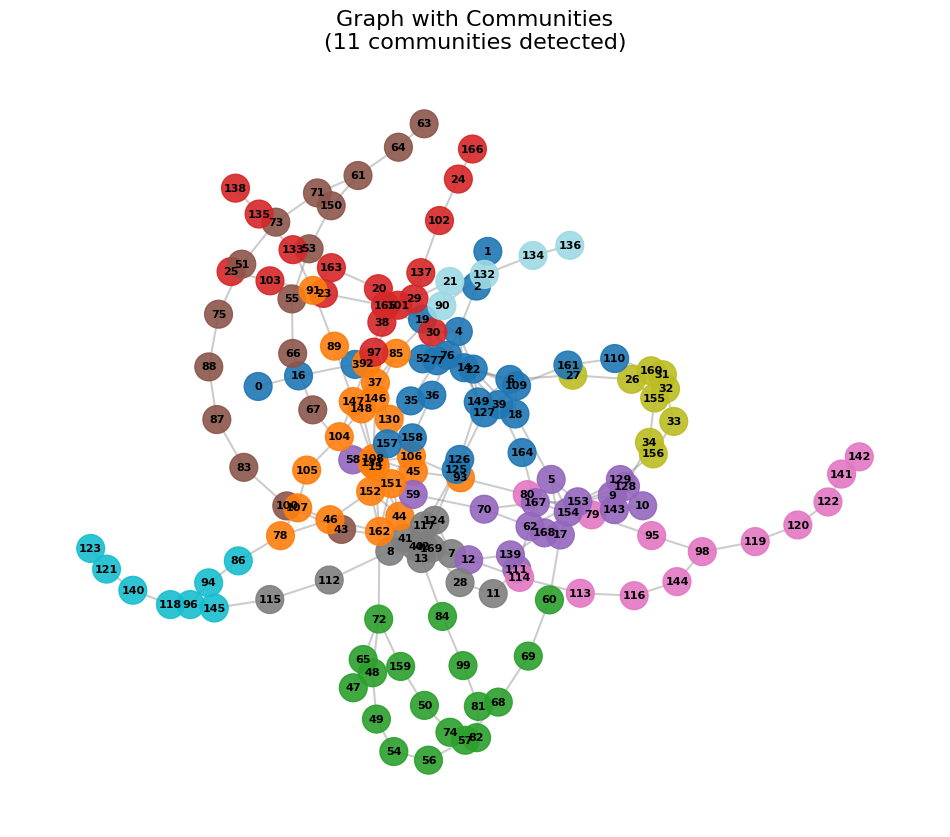

In [3]:
from src.utils.visualization import (
    plot_adjacency_matrix_heatmap,
    draw_graph_network,
    draw_graph_communities,
    draw_graph_components,
    draw_graph_with_hubs,
    plot_degree_distribution,
    compare_adjacency_matrices_heatmap,
    plot_node_time_series,
    plot_time_series_decomposition,
)

draw_graph_communities(adj_mx)

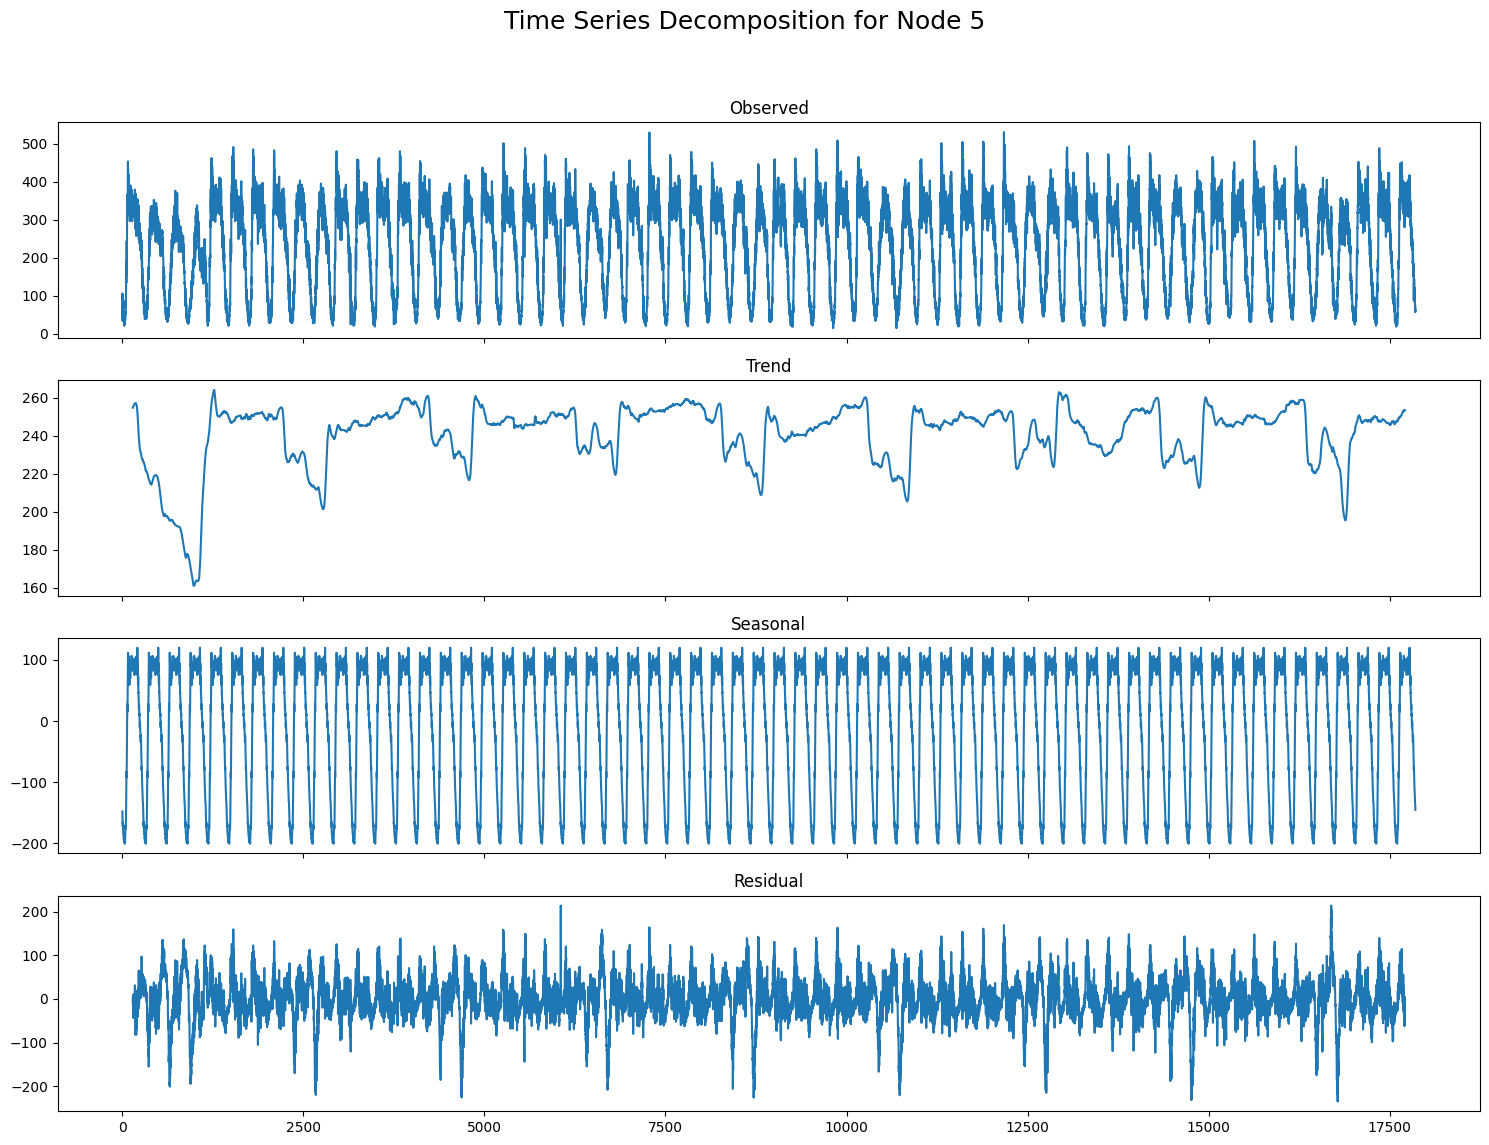

In [4]:
plot_time_series_decomposition(data, 5, frequency=288)

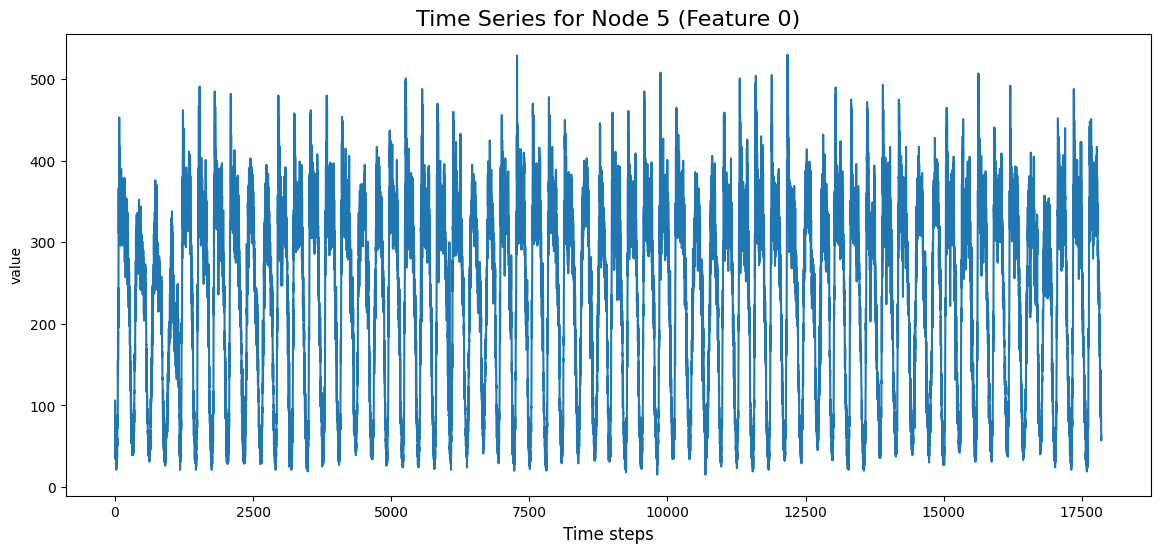

In [5]:
plot_node_time_series(data, 5)

In [6]:
from src.matrix_generation import PearsonCorrelationGenerator

In [7]:
pearson = PearsonCorrelationGenerator(0)
corr = pearson.generate(data)

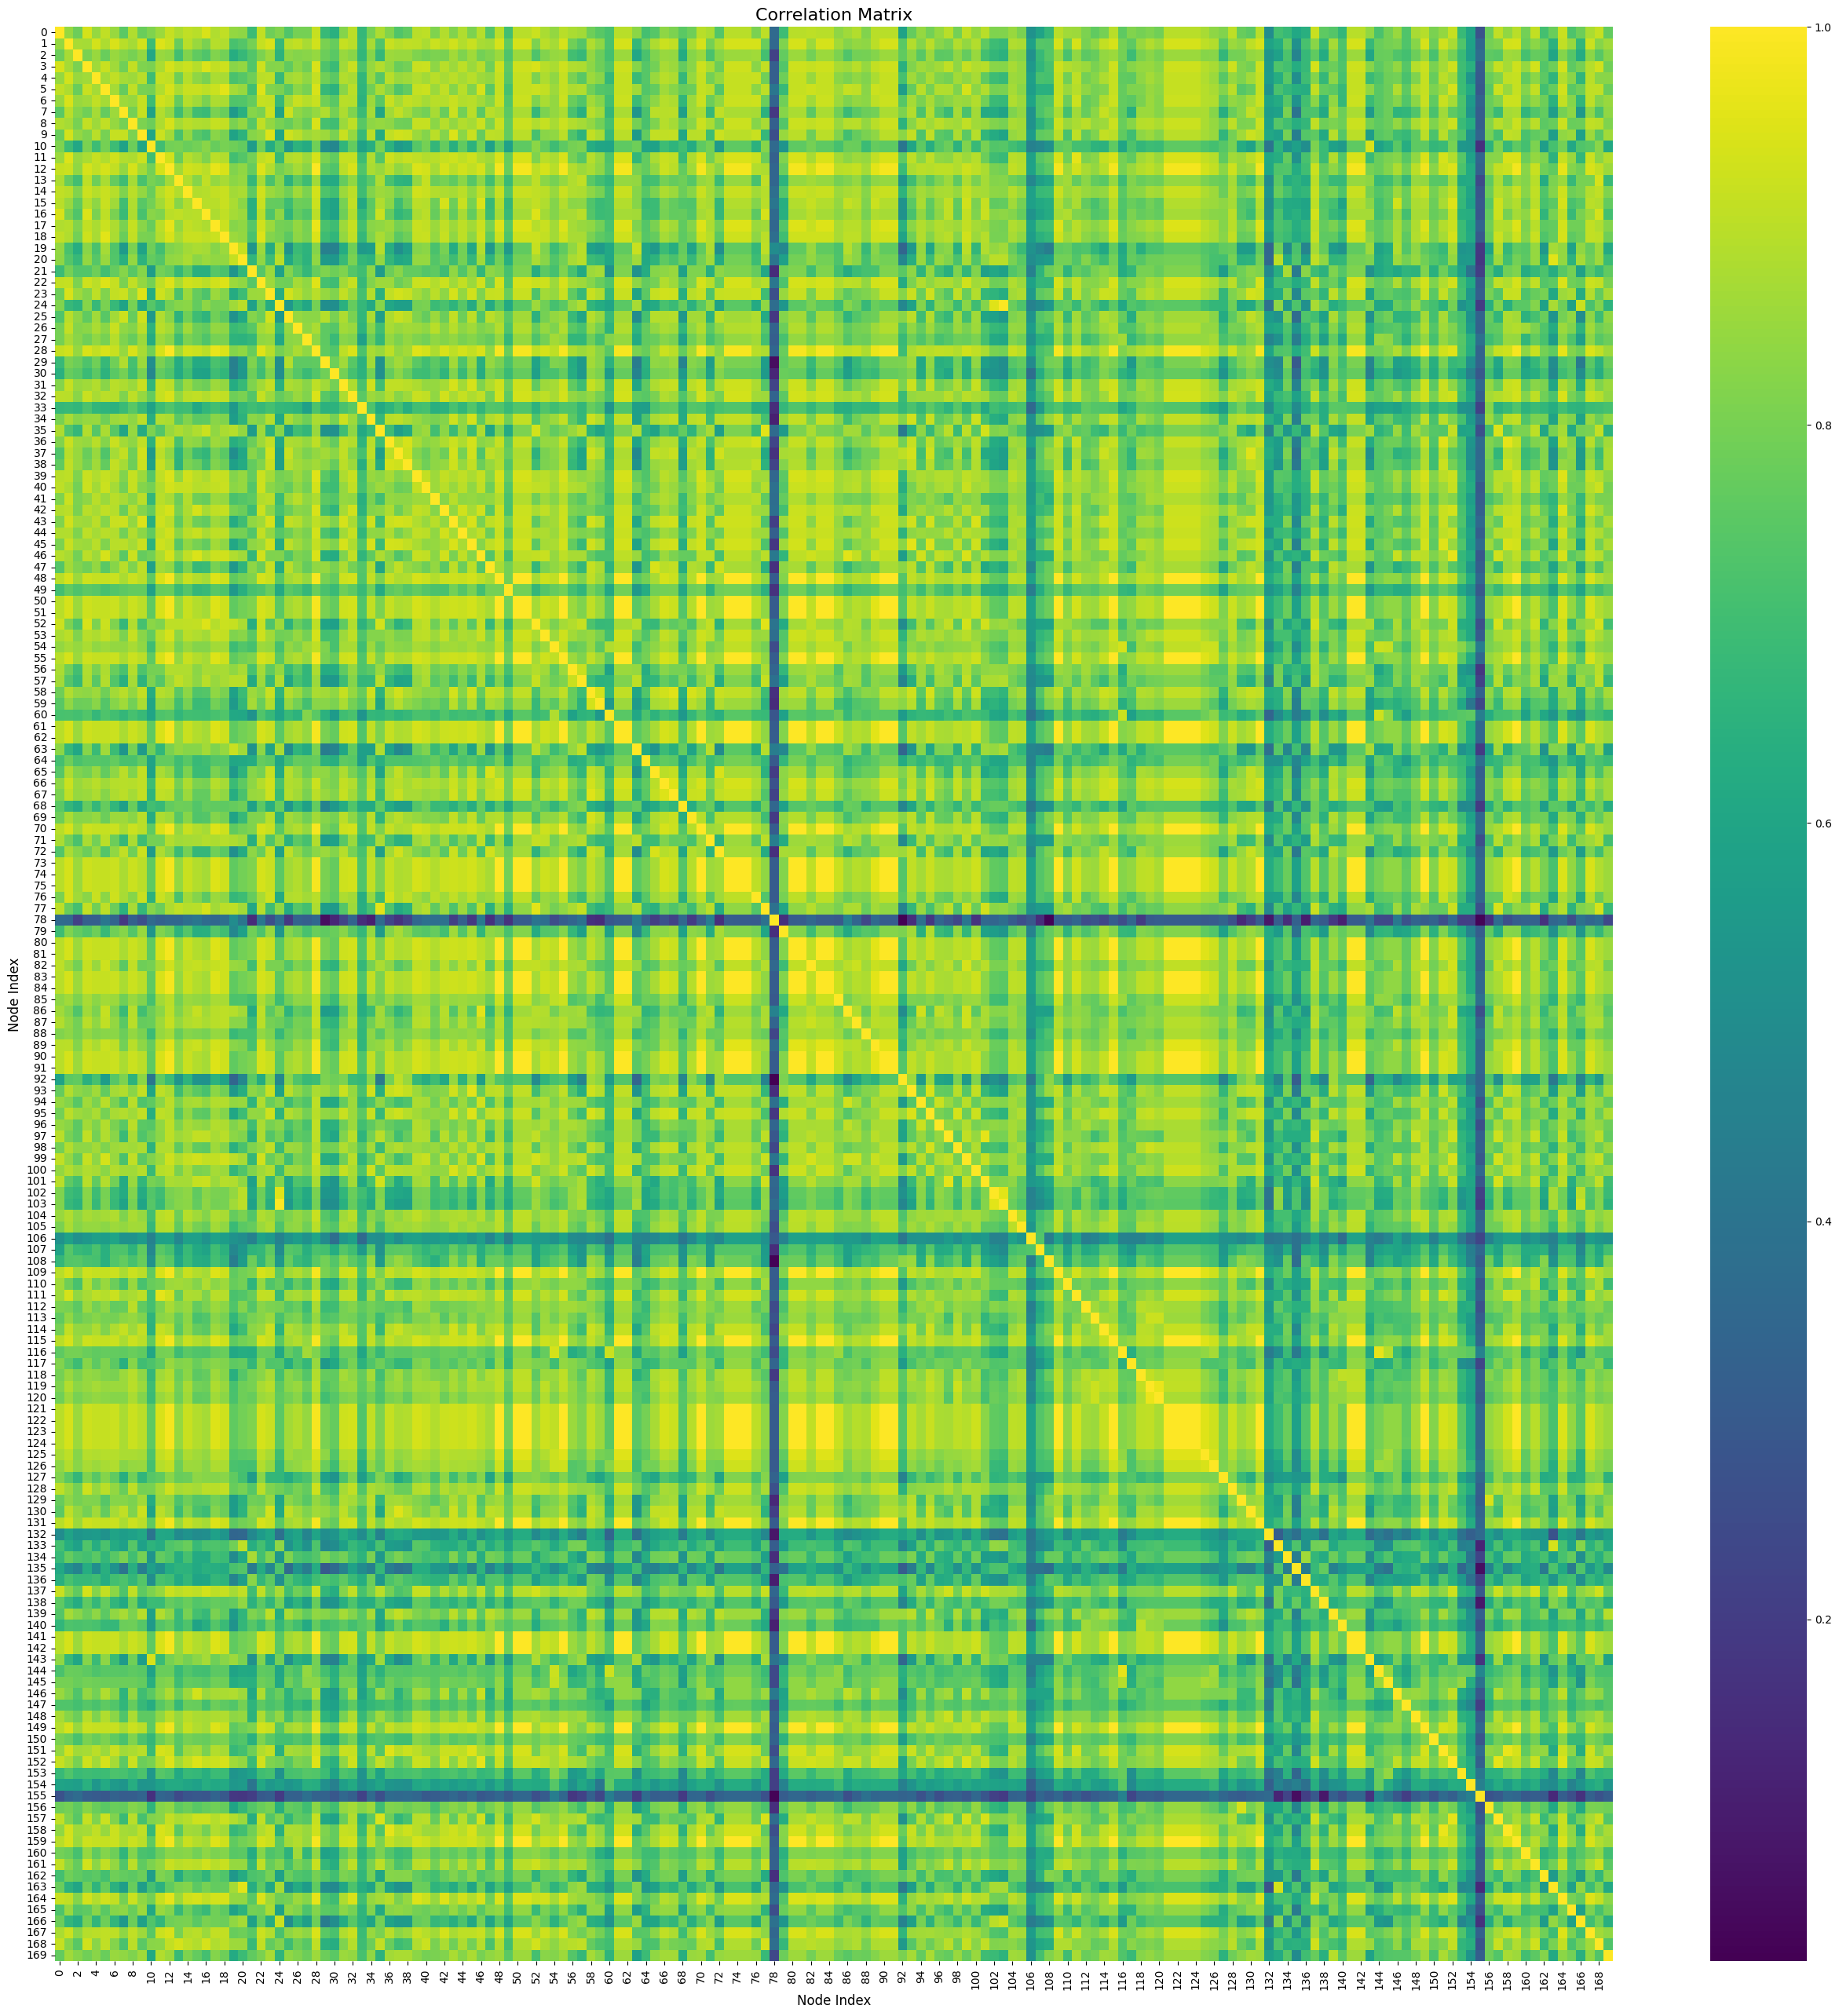

In [8]:
plot_adjacency_matrix_heatmap(corr, "Correlation Matrix", figsize=(32,32))

In [17]:
from src.sparcification import make_adjacency_matrix

mtr = (make_adjacency_matrix(corr, 255, 'spectral-sparce', 'make-1'))

In [11]:
from src.data.loaders import load_pkl

In [21]:
temp = load_pkl('../results/temp.png')

In [22]:
from src.utils.graph_metrics import compare_adjacency_matrices
compare_adjacency_matrices(temp, corr)

{'num_nodes': 170,
 'num_edges_A': 28900,
 'num_edges_B': 28900,
 'avg_degree_A': 170.0,
 'avg_degree_B': 170.0,
 'abs_error_weighted': 0.0004172392858732901,
 'abs_error_binary': 0.0,
 'error_per_node_weighted': 2.4543487404311183e-06,
 'error_per_node_binary': 0.0,
 'frobenius_error': 2.873887702718417e-06,
 'common_edges': 28900,
 'jaccard_similarity': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 0.9999999999995,
 'cosine_similarity': 1.0000000000000009,
 'pearson_corr': 0.9999999999999923,
 'out_degree_corr': 1.0,
 'in_degree_corr': 1.0,
 'spectral_distance': 3.707902041103239e-07,
 'laplacian_spectral_distance': 2.7954288550194548e-06,
 'graph_energy_diff': 1.1272641131654382e-06}